# Optimizing Raw Material Inventory Management of MSME Product Using XGBoost Regressor
## A Sales Prediction Approach

This notebook implements the data processing and modeling pipeline described in the paper:  
*Optimizing raw ...* by Muhammad Khusni Fikri, et al.

### Table of Contents
1. Import Libraries
2. Data Collection (Simulated)
3. Data Understanding & Preprocessing
    - Feature Reengineering
    - Data Integration
    - Data Cleansing
4. Data Modeling
    - Descriptive Analysis
    - Predictive Analysis (XGBoost)
5. Evaluation

### 1. Import Librairies

In [1]:
import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error
import matplotlib.pyplot as plt
import seaborn as sns

# Set seed for reproducibility
np.random.seed(42)

### 2. Data Collection (Simulated)
Since the original dataset is not publicly available, we will simulate the data based on the characteristics described.
- **Sales Data**: Contains transactions from January 2023, to June 2023 (6 months), with features like `Date`, `Order mode` (Dine in, Online, Take Away), `Quantity` and `Value` (Roupies).
- **Weather Data**: Contains `Date`, `Avg temperature (°C)`, and `Avg humidity (%)` for Semarang City.

In [11]:
# Simulate Dates
dates = pd.date_range(start='2023-01-01', end='2023-06-30')

# Simulate Sales Data
modes = ['Dine in', 'Online', 'Take Away']
sales_data_list = []

for date in dates:
    for mode in modes:
        if np.random.rand() > 0.1: 
        # 90% chance to have sales for this mode on this day
            if mode == 'Dine in':
                qty = np.random.randint(1, 50)
            else:
                qty = np.random.randint(1, 20)
            sales_data_list.append({'Date': date, 'Order_mode': mode, 'Quantity': qty, 'Value': qty*40000}) # 40k is the avg price

df_sales_raw = pd.DataFrame(sales_data_list)
print("Raw Sales Data Sample:")
display(df_sales_raw.head())

# Simulate Weather Data
weather_data = pd.DataFrame({
    'Date': dates,
    'Avg_temp': np.random.uniform(26.0, 32.0, len(dates)),
    'Avg_humidity': np.random.uniform(70.0, 90.0, len(dates))
})
print("\nWeather Data Sample:")
display(weather_data.head())

Raw Sales Data Sample:


,Date,Order_mode,Quantity,Value
0,2023-01-01,Dine in,17,680000
1,2023-01-01,Online,12,480000
2,2023-01-01,Take Away,8,320000
3,2023-01-02,Dine in,18,720000
4,2023-01-02,Online,12,480000



Weather Data Sample:


,Date,Avg_temp,Avg_humidity
0,2023-01-01,30.619601,87.355641
1,2023-01-02,31.144912,77.402958
2,2023-01-03,26.001111,71.423105
3,2023-01-04,28.174588,87.882146
4,2023-01-05,30.425619,87.763799


### 3. Data Understanding

Affichage visuel des ventes au fil des jours

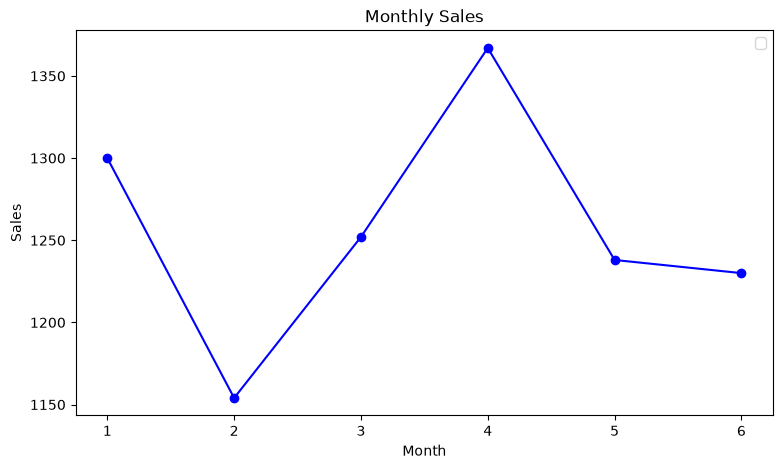

In [22]:
import matplotlib.pyplot as plt

# 1. Préparation des données (Extraction du mois et calcul de la somme)
# On s'assure d'abord que la colonne Date est bien au format 'datetime'
df_sales_raw['Date'] = pd.to_datetime(df_sales_raw['Date'])

# On crée une nouvelle colonne 'Month' (qui contiendra 1 pour Janvier, 2 pour Février, etc.)
df_sales_raw['Month'] = df_sales_raw['Date'].dt.month

# On groupe par mois et on additionne toutes les ventes
monthly_sales = df_sales_raw.groupby('Month')['Sales Quantity'].sum()

# 2. Création du graphique reproduisant la Figure 7
plt.figure(figsize=(9, 5)) # Ajustement de la taille pour correspondre à l'image

# Tracé de la courbe : ligne bleue ('b'), avec un marqueur rond ('o') et une ligne continue ('-')
plt.plot(monthly_sales.index, monthly_sales.values, color='blue', marker='o', linestyle='-')

# Ajout des titres et labels exacts de l'image
plt.title('Monthly Sales')
plt.xlabel('Month')
plt.ylabel('Sales')

# Ajout de la légende (même si elle est vide sur l'image d'origine)
plt.legend([])

# Affichage final du graphique
plt.show()

### 4. Data Preprocessing
#### 4.1 Feature Reengineering

In [12]:
# Keep only intresting features
df_sales_raw = df_sales_raw[['Date', 'Order_mode', 'Quantity']]
df_sales_raw.rename(columns={'Order_mode': 'Mode', 'Quantity': 'Sales Quantity'}, inplace=True)

# Group by Date with sum (not useful for me as I created daily data)
df_sum = df_sales_raw.groupby([pd.Grouper(key='Date'), pd.Grouper(key='Mode')])['Sales Quantity'].sum().reset_index()
data_sum_daily = pd.DataFrame(df_sum)

# Create a pivot table to have Modes as columns
data_transpose = data_sum_daily.pivot(index='Date', columns='Mode', values='Sales Quantity')
print("Feature Reengineered Data:")
display(data_transpose.head())

Feature Reengineered Data:


Mode,Dine in,Online,Take Away
Date,,,
2023-01-01,17.0,12.0,8.0
2023-01-02,18.0,12.0,4.0
2023-01-03,8.0,11.0,NaN
2023-01-04,15.0,18.0,14.0
2023-01-05,39.0,16.0,7.0


#### 4.2 Data Integration
Merging the sales data with the weather data based on the `Date`.

In [13]:
data_final = pd.merge(data_transpose, weather_data, on='Date', how='inner')
print("Integrated Data Sample:")
display(data_final.head())

Integrated Data Sample:


,Date,Dine in,Online,Take Away,Avg_temp,Avg_humidity
0,2023-01-01,17.0,12.0,8.0,30.619601,87.355641
1,2023-01-02,18.0,12.0,4.0,31.144912,77.402958
2,2023-01-03,8.0,11.0,NaN,26.001111,71.423105
3,2023-01-04,15.0,18.0,14.0,28.174588,87.882146
4,2023-01-05,39.0,16.0,7.0,30.425619,87.763799


#### 4.3 Data Cleansing
Filling missing values (NaN) with 0, as some days might not have sales for a specific mode.

In [16]:
data_final.fillna(0, inplace=True)
print("Cleaned Data Sample:")
display(data_final.head())

Cleaned Data Sample:


,Date,Dine in,Online,Take Away,Avg_temp,Avg_humidity
0,2023-01-01,17.0,12.0,8.0,30.619601,87.355641
1,2023-01-02,18.0,12.0,4.0,31.144912,77.402958
2,2023-01-03,8.0,11.0,0.0,26.001111,71.423105
3,2023-01-04,15.0,18.0,14.0,28.174588,87.882146
4,2023-01-05,39.0,16.0,7.0,30.425619,87.763799


### 5. Data Modeling
#### 5.1 Descriptive Analysis
Correlation analysis to understand the relationship between weather features and sales.

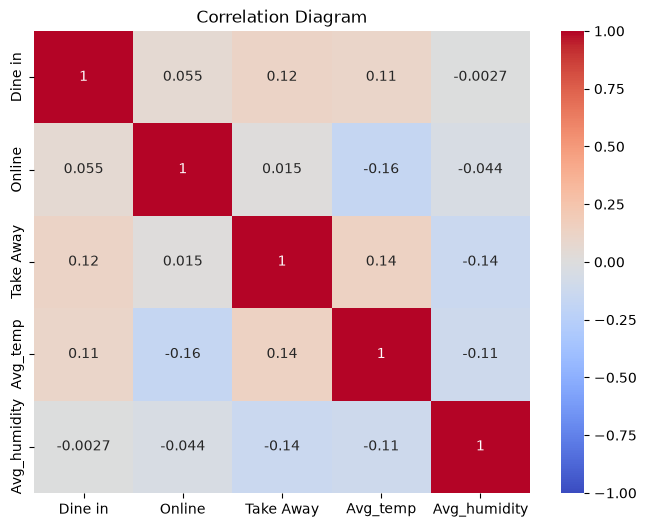

In [18]:
# Calculate correlation matrix
corr = data_final[['Dine in', 'Online', 'Take Away', 'Avg_temp', 'Avg_humidity']].corr()

# Plot correlation matrix using Seaborn
plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title("Correlation Diagram")
plt.show()

#### 5.2 Predictive Analysis (XGBoost)
Training an XGBoost Regressor model to predict sales based on average temperature and average humidity.

In [20]:
# Features (X) and Targets (y)
X = data_final[['Avg_temp', 'Avg_humidity']]
y = data_final[['Dine in', 'Online', 'Take Away']]

# Train-Test Split (80% training, 20% testing)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize XGBoost Regressor
model = xgb.XGBRegressor(
    max_depth=3,
    n_estimators=100,
    learning_rate=0.1,
    objective='reg:squarederror'
)

# Train the model
model.fit(X_train, y_train)
print("Model training completed.")

Model training completed.


### 6. Evaluation
Evaluating the model using Mean Absolute Error (MAE), Mean Squared Error (MSE), and Root Mean Squared Error.

Mean Squared Error: 148.19172668457031
Mean Absolute Error: 8.71535396575928
Root Mean Squared Error: 12.17340242843266


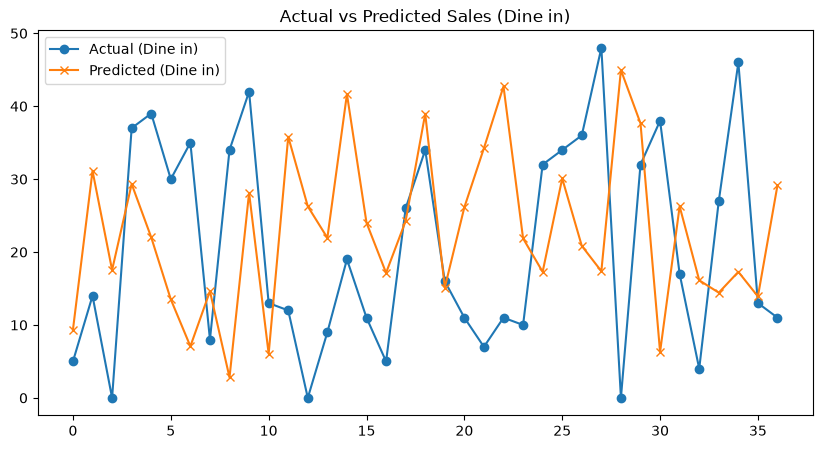

In [21]:
# Predict on test data
predictions = model.predict(X_test)

# Calculate metrics
mse = mean_squared_error(y_test, predictions)
mae = mean_absolute_error(y_test, predictions)
rmse = np.sqrt(mean_squared_error(y_test, predictions))

print(f"Mean Squared Error: {mse:.14f}")
print(f"Mean Absolute Error: {mae:.14f}")
print(f"Root Mean Squared Error: {rmse:.14f}")

# Visualizing the predictions vs actuals for the first target (Dine in) as an example
plt.figure(figsize=(10, 5))
plt.plot(y_test['Dine in'].values, label='Actual (Dine in)', marker='o')
plt.plot(predictions[:, 0], label='Predicted (Dine in)', marker='x')
plt.title('Actual vs Predicted Sales (Dine in)')
plt.legend()
plt.show()

#### Conclusion on the results
The differences between my error indicators and those in the papers are normal as my data consists of samples.